# 1. Introduction

This project analyzes the *Fitbit Fitness Tracker Data* to examine how daily activity levels relate to heart rate and sleep patterns.

# 2. Data Overview

This analysis focuses on three datasets from the Fitbit Fitness Tracker Data:

- **Heart rate data**: Includes time-stamped heart rate measurements for each user  
- **Activity data**: Contains daily metrics such as steps taken, distance traveled, calories burned, and activity intensity levels  
- **Sleep data**: Provides information on sleep duration  

These datasets are linked by user ID and date, allowing for analysis of how activity levels relate to heart rate and sleep behavior.

### Importing packages and data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
heartrate = pd.read_csv("/kaggle/input/datasets/arashnic/fitbit/mturkfitbit_export_3.12.16-4.11.16/Fitabase Data 3.12.16-4.11.16/heartrate_seconds_merged.csv")
activity = pd.read_csv("/kaggle/input/datasets/arashnic/fitbit/mturkfitbit_export_3.12.16-4.11.16/Fitabase Data 3.12.16-4.11.16/dailyActivity_merged.csv")
sleep = pd.read_csv("/kaggle/input/datasets/arashnic/fitbit/mturkfitbit_export_3.12.16-4.11.16/Fitabase Data 3.12.16-4.11.16/minuteSleep_merged.csv")

Each dataset was inspected to understand structure, column names, and data types before merging.

# 3. Data Cleaning

In [3]:
# Sort values by time, limit dataset for efficiency
heartrate_sorted = heartrate.sort_values('Time').head(500000)

# Convert 'Time' from object to datetime
heartrate_sorted['Time'] = pd.to_datetime(heartrate_sorted['Time'])
heartrate_sorted['Date'] = heartrate_sorted['Time'].dt.date

# Group by Id and Date, then average Value
daily_heart = heartrate_sorted.groupby(['Id', 'Date'])['Value'].mean().reset_index()

# rename Value column
daily_heart = daily_heart.rename(columns={'Value': 'Avg_Heart_Rate'})

daily_heart.head()

,Id,Date,Avg_Heart_Rate
0,2022484408,2016-04-01,88.563916
1,2022484408,2016-04-02,72.068685
2,2022484408,2016-04-03,71.860292
3,2022484408,2016-04-10,80.388544
4,2022484408,2016-04-11,81.606318


Due to the high granularity of second-level heart rate data, a subset of the dataset was used to improve computational efficiency while preserving representative patterns.

The timestamp column was converted to datetime format, and a date column was extracted.

To match the daily activity and sleep data, heart rate values were aggregated by user and date to calculate average daily heart rate.

In [4]:
# Convert ActivityDate to datettime
activity['ActivityDate'] = pd.to_datetime(activity['ActivityDate']).dt.date

# Merge Daily Activity + Daily Heartrate

activity_heart_df = pd.merge(
    activity,
    daily_heart,
    left_on=['Id', 'ActivityDate'],
    right_on=['Id', 'Date'],
    how='inner'
)


# Drop extra date column
activity_heart_df = activity_heart_df.drop(columns=['Date'])

activity_heart_df.head()

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories,Avg_Heart_Rate
0,2022484408,2016-04-01,13603,9.60,9.60,0.0,5.46,0.63,3.51,0.0,72,16,213,1139,2645,88.563916
1,2022484408,2016-04-02,5477,3.84,3.84,0.0,0.00,0.00,3.84,0.0,0,0,237,1203,2040,72.068685
2,2022484408,2016-04-03,11144,7.82,7.82,0.0,1.79,0.89,5.14,0.0,25,22,279,1114,2395,71.860292
3,2022484408,2016-04-10,10005,7.02,7.02,0.0,0.08,1.05,5.90,0.0,1,23,339,1077,2458,80.388544
4,2022484408,2016-04-11,10106,7.09,7.09,0.0,1.21,0.56,5.33,0.0,41,16,272,1111,2568,81.606318


The activity dataset’s date column was converted to datetime format to match the heart rate data.

The activity and aggregated heart rate datasets were then merged using user ID and date, aligning daily activity metrics with corresponding average heart rate values. An inner join was used to retain only records present in both datasets.

After merging, the redundant date column was removed to streamline the final dataset.

In [5]:
# Convert SleepDay to datetime
sleep['SleepDay'] = pd.to_datetime(sleep['date']).dt.date

# Remove duplicate date column from sleep
sleep = sleep.drop(columns=['date'])

# Sum sleep per day
daily_sleep = (
    sleep.groupby(['Id', 'SleepDay'])['value']
    .sum()
    .reset_index()
)

# Rename columns
daily_sleep = daily_sleep.rename(columns={'value': 'TotalMinutesAsleep'})
daily_sleep = daily_sleep.rename(columns={'SleepDay': 'Date'})


# Merge sleep dataset

merged_df = pd.merge(
    activity_heart_df,
    daily_sleep,
    left_on=['Id', 'ActivityDate'],
    right_on=['Id', 'Date'],
    how='inner'
)

# Remove duplicate date column and rename ActivityDate column

merged_df = merged_df.drop(columns=['Date'])
merged_df.head()

merged_df = merged_df.rename(columns={'ActivityDate': 'Date'})

merged_df.head()

,Id,Date,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories,Avg_Heart_Rate,TotalMinutesAsleep
0,2026352035,2016-04-02,1229,0.76,0.76,0.0,0.00,0.00,0.76,0.0,0,0,69,795,1237,65.779043,630
1,2347167796,2016-03-29,10272,6.79,6.79,0.0,0.16,3.12,3.50,0.0,2,58,208,700,2041,71.264220,527
2,2347167796,2016-03-30,10533,7.10,7.10,0.0,1.77,2.06,3.27,0.0,21,35,255,615,2187,72.835195,563
3,2347167796,2016-03-31,6760,4.47,4.47,0.0,0.00,0.00,4.47,0.0,0,0,250,613,1929,70.711957,643
4,2347167796,2016-04-01,8328,5.51,5.51,0.0,0.00,2.00,3.50,0.0,0,33,212,804,1935,69.234380,410


The sleep dataset was cleaned by converting the date column to a standard format and removing the redundant original date field. Sleep duration was then aggregated by user and date to calculate total minutes asleep per day.

This daily sleep dataset was merged with the activity and heart rate data using user ID and date, creating a unified dataset for analysis. After merging, redundant date columns were removed and standardized into a single 'Date' column for consistency.

In [6]:
merged_df.shape
list(merged_df.columns)

['Id',
 'Date',
 'TotalSteps',
 'TotalDistance',
 'TrackerDistance',
 'LoggedActivitiesDistance',
 'VeryActiveDistance',
 'ModeratelyActiveDistance',
 'LightActiveDistance',
 'SedentaryActiveDistance',
 'VeryActiveMinutes',
 'FairlyActiveMinutes',
 'LightlyActiveMinutes',
 'SedentaryMinutes',
 'Calories',
 'Avg_Heart_Rate',
 'TotalMinutesAsleep']

The final dataset contains daily records for each user, combining activity, heart rate, and sleep data.

Key variables include:
- **Activity**: steps, distance, calories, and intensity metrics  
- **Heart Rate**: Avg_Heart_Rate  
- **Sleep**: TotalMinutesAsleep  

# 4. Exploratory Analysis

This section explores relationships between activity, heart rate, and sleep to identify patterns and relationships in user behavior.

## 1. Activity vs Heart Rate

### *Question: Do higher activity levels lead to higher average heart rate?*

In [7]:
# Create 'Activity Level' column

merged_df['ActivityLevel'] = pd.cut(
    merged_df['VeryActiveMinutes'],
    bins=[-1, 10, 30, 60, 200],
    labels=['Low', 'Moderate', 'High', 'Very High']
)

merged_df[['VeryActiveMinutes', 'ActivityLevel']].head()

,VeryActiveMinutes,ActivityLevel
0,0,Low
1,2,Low
2,21,Moderate
3,0,Low
4,0,Low


Activity levels were categorized based on minutes of very active movement to simplify interpretation and highlight differences across intensity levels.

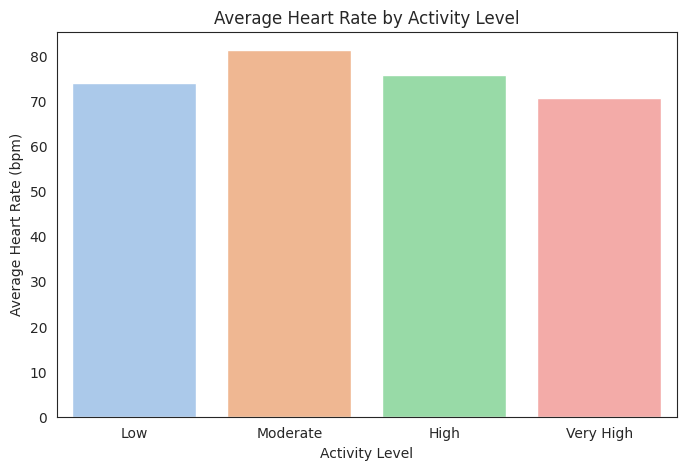

In [8]:
sns.set_style("white")
sns.set_palette("pastel")

plt.figure(figsize=(8,5))

sns.barplot(
    data=merged_df,
    x='ActivityLevel',
    y='Avg_Heart_Rate',
    palette='pastel', hue='ActivityLevel',
    order=['Low', 'Moderate', 'High', 'Very High'],
    errorbar=None, legend=None
)

plt.title('Average Heart Rate by Activity Level')
plt.xlabel('Activity Level')
plt.ylabel('Average Heart Rate (bpm)')

plt.show()

In [9]:
merged_df['ActivityLevel'].value_counts()

ActivityLevel
Low          23
Moderate      8
High          8
Very High     3
Name: count, dtype: int64

Average heart rate increases from low to moderate activity levels but does not continue rising at the highest levels, suggesting a non-linear relationship.

The distribution of activity levels is imbalanced, with most observations in the ‘Low’ category. This imbalance may limit the reliability of comparisons, particularly for the ‘Very High’ group.

## 2. Steps vs Heart Rate

#### *Question: As steps increase, does average heart rate also increase?*


In [10]:
# Aggregate across all users per day

daily_summary = merged_df.groupby('Date').agg({
    'TotalSteps': 'mean',
    'Avg_Heart_Rate': 'mean'
}).reset_index()

daily_summary.head()

,Date,TotalSteps,Avg_Heart_Rate
0,2016-03-29,10272.000,71.264220
1,2016-03-30,13012.000,73.909313
2,2016-03-31,10428.500,75.765558
3,2016-04-01,8284.625,77.894759
4,2016-04-02,8703.900,75.904645


Text(0.5, 1.0, 'Relationship Between Daily Steps and Average Heart Rate')

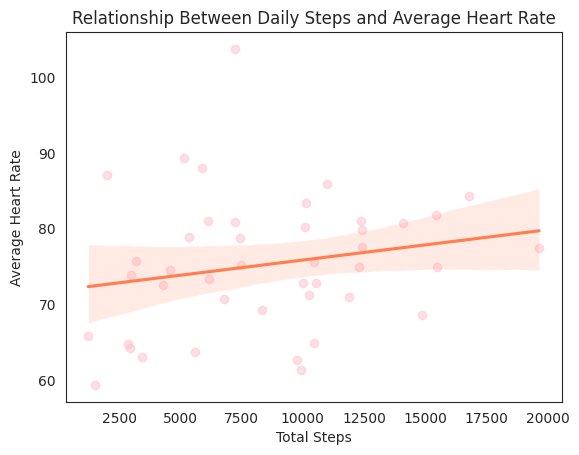

In [11]:
sns.regplot(
    x='TotalSteps',
    y='Avg_Heart_Rate',
    data=merged_df,
    scatter_kws={'color':'pink','alpha':0.5},
    line_kws={'color':'coral'}
)

plt.xlabel('Total Steps')
plt.ylabel('Average Heart Rate')
plt.title('Relationship Between Daily Steps and Average Heart Rate')

This suggests that step count alone is not a strong predictor of heart rate, and that other factors likely play a role.

To further explore this relationship, we analyzed how heart rate varies across different step levels.

#### *Question: How does heart rate distribution change across different levels of steps or distance?*


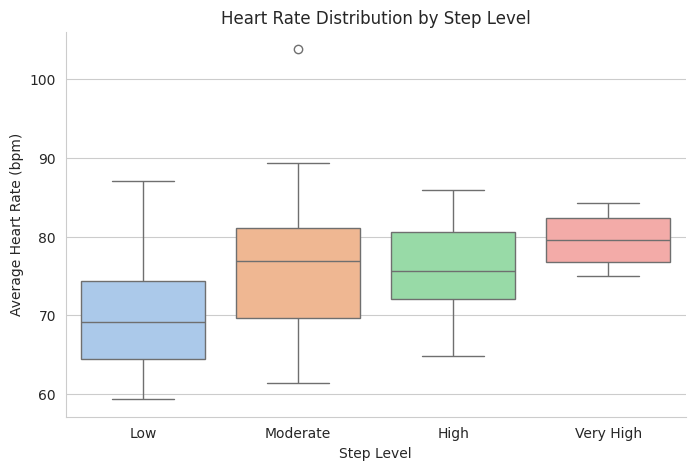

In [12]:
# Add column for 'Step Level'
merged_df['StepLevel'] = pd.cut(
    merged_df['TotalSteps'],
    bins=[-1, 5000, 10000, 15000, 30000],
    labels=['Low', 'Moderate', 'High', 'Very High']
)

sns.set_style("whitegrid")
sns.set_palette("pastel")

plt.figure(figsize=(8,5))

sns.boxplot(
    data=merged_df,
    x='StepLevel',
    y='Avg_Heart_Rate',
    palette='pastel', hue='StepLevel',
    order=['Low', 'Moderate', 'High', 'Very High']
)

plt.title('Heart Rate Distribution by Step Level')
plt.xlabel('Step Level')
plt.ylabel('Average Heart Rate (bpm)')

sns.despine()
plt.show()

In [13]:
merged_df['StepLevel'].value_counts()

StepLevel
High         15
Moderate     14
Low          10
Very High     4
Name: count, dtype: int64

Heart rate distributions show a clear upward trend across increasing step levels. Both the median and overall distribution shift higher as step counts increase, suggesting a clearer relationship between categorized step levels and heart rate compared to raw step values.

Text(0, 0.5, 'Average Heart Rate (bpm)')

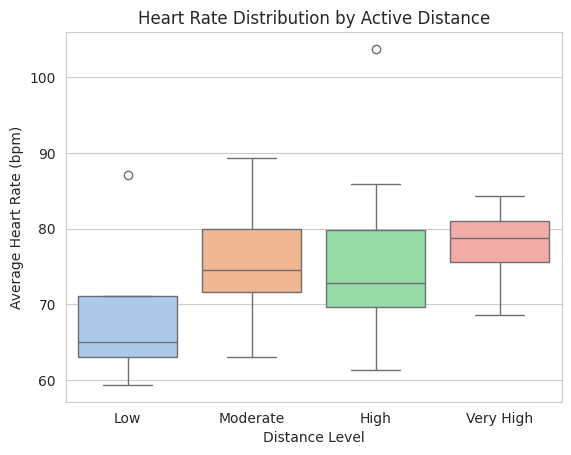

In [14]:
# Add column for 'Distance Level'
merged_df['DistanceLevel'] = pd.cut(
    merged_df['TotalDistance'],
    bins=[-1, 2, 5, 8, 20],
    labels=['Low', 'Moderate', 'High', 'Very High']
)

sns.boxplot(
    data=merged_df,
    x='DistanceLevel',
    y='Avg_Heart_Rate',
    palette='pastel',
    hue='DistanceLevel'
)

plt.title('Heart Rate Distribution by Active Distance')
plt.xlabel('Distance Level')
plt.ylabel('Average Heart Rate (bpm)')

In [15]:
merged_df['DistanceLevel'].value_counts()

DistanceLevel
Moderate     15
High         14
Very High    10
Low           4
Name: count, dtype: int64

Heart rate generally increases across higher distance categories, though there is noticeable overlap between groups, indicating variability within each activity level.

#### Key Insight:
While continuous variables like steps and distance show weak relationships with heart rate, grouping them into categories reveals clearer trends.

## 3. Sleep vs Heart Rate

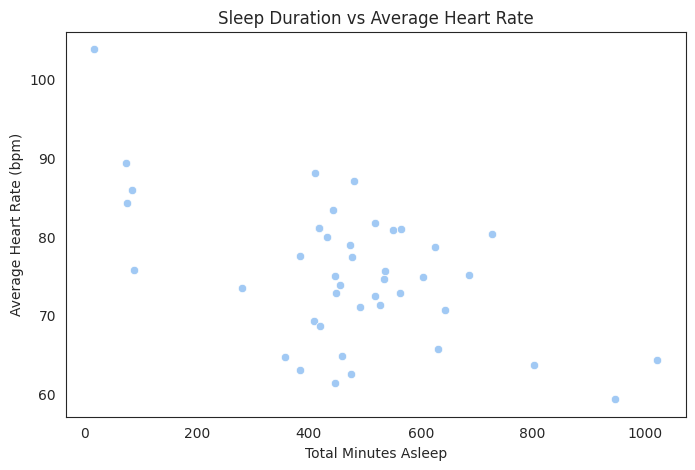

In [16]:
sns.set_style("white")
sns.set_palette("pastel")

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=merged_df,
    x='TotalMinutesAsleep',
    y='Avg_Heart_Rate'
)


plt.title('Sleep Duration vs Average Heart Rate')
plt.xlabel('Total Minutes Asleep')
plt.ylabel('Average Heart Rate (bpm)')

plt.show()

There is no clear relationship between sleep duration and average heart rate. The data points are widely scattered, indicating high variability. This suggests that sleep duration alone is not a strong predictor of heart rate in this dataset.

## 4. Sleep vs Steps

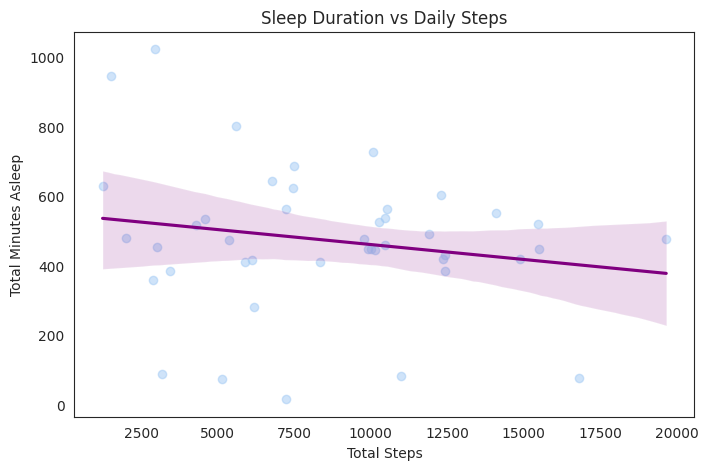

In [17]:
sns.set_style("white")
sns.set_palette("pastel")

plt.figure(figsize=(8,5))

sns.regplot(
    data=merged_df,
    x='TotalSteps',
    y='TotalMinutesAsleep',
    scatter_kws={'alpha':0.5},
    line_kws={'color':'purple'}
)

plt.title('Sleep Duration vs Daily Steps')
plt.xlabel('Total Steps')
plt.ylabel('Total Minutes Asleep')

plt.show()

There is no clear relationship between daily steps and sleep duration. The regression line shows a slight negative trend, but the wide spread of data points indicates high variability.

In [18]:
from scipy.stats import pearsonr

r, p = pearsonr(merged_df['TotalSteps'], merged_df['TotalMinutesAsleep'])

print("Correlation (r):", r)
print("P-value:", p)

Correlation (r): -0.18686533956541956
P-value: 0.23019612150870336


A Pearson correlation test revealed a weak negative relationship between daily steps and sleep duration (r = -0.19), which was not statistically significant (p = 0.23). This suggests that there is no meaningful association between daily steps and sleep duration in this dataset.

# 5. Key Findings

* **Steps and distance show weak relationships with heart rate.**
While there is a slight positive trend, the data is highly variable, so overall activity volume is not a strong predictor of heart rate.
* **Categorizing activity levels reveals clearer trends.**
Once the data is grouped into categories, the patterns become much easier to see.
* **Heart rate increases with higher activity levels.**
Across activity categories, heart rate generally shifts upward, suggesting a positive relationship between activity intensity and cardiovascular response.
* **Sleep duration does not show a clear relationship with heart rate.**
Sleep duration is widely spread across heart rate values, with no consistent pattern.
* **Steps and sleep are not meaningfully associated.**
The relationship between daily steps and sleep duration is weak and not statistically significant, meaning increased activity does not consistently lead to more sleep.
* **Data limitations affect interpretation.**
Some activity categories have fewer observations, which makes comparisons at higher activity levels less reliable.

# 6. Conclusion

This project explored how daily activity, heart rate, and sleep are related using Fitbit data. Overall, activity does appear to influence heart rate, but the relationship isn’t very strong or perfectly consistent.

When looking at raw variables like steps and distance, the relationship with heart rate was weak and highly variable. However, after grouping activity into categories, clearer patterns started to emerge, with higher activity levels generally associated with higher heart rates. This shows how grouping raw data can make trends easier to see and interpret.

Sleep duration, on the other hand, did not show a clear relationship with heart rate. Additionally, the correlation analysis between steps and sleep confirmed that there is no meaningful association between the two in this dataset. This suggests that factors beyond activity level likely play a larger role in influencing sleep patterns and cardiovascular response.

There are some limitations to consider. The dataset is relatively small, and higher activity levels had fewer observations, which may affect how reliable those comparisons are. With more data, some of these relationships might become clearer.